In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import datetime as dt

print("Libraries loaded ✅")

Libraries loaded ✅


In [3]:
master_df = pd.read_csv("master_olist_dataset.csv")

In [4]:
from mpl_toolkits.mplot3d import Axes3D

In [5]:
import datetime as dt
 
# Use only delivered orders
delivered = master_df[master_df['order_status'] == 'delivered'].copy()
delivered['order_purchase_timestamp'] = pd.to_datetime(delivered['order_purchase_timestamp'])
 
snapshot_date = delivered['order_purchase_timestamp'].max() + dt.timedelta(days=1)
 
rfm = delivered.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('price', 'sum')
).reset_index()
 
print("RFM table shape:", rfm.shape)
rfm.head()
 

RFM table shape: (93358, 4)


,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90
2,0000f46a3911fa3c0805444483337064,537,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00


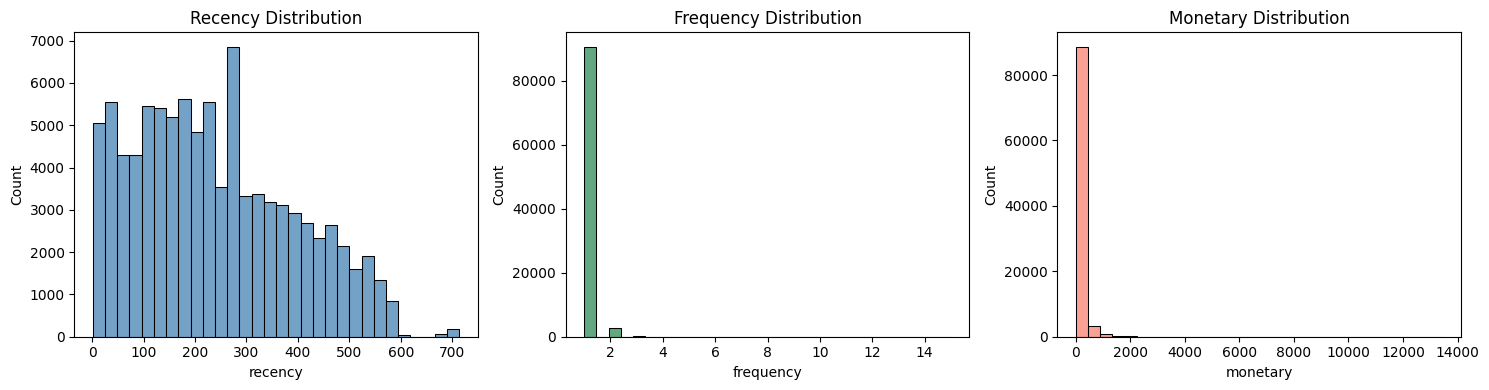

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(rfm['recency'], bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Recency Distribution')
 
sns.histplot(rfm['frequency'], bins=30, ax=axes[1], color='seagreen')
axes[1].set_title('Frequency Distribution')
 
sns.histplot(rfm['monetary'], bins=30, ax=axes[2], color='salmon')
axes[2].set_title('Monetary Distribution')
 
plt.tight_layout()
plt.show()

In [7]:
 
rfm['monetary_log'] = np.log1p(rfm['monetary'])
rfm['frequency_log'] = np.log1p(rfm['frequency'])
 
rfm_features = rfm[['recency', 'frequency_log', 'monetary_log']]
 

In [8]:

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)
 
print("Scaled shape:", rfm_scaled.shape)
 

Scaled shape: (93358, 3)


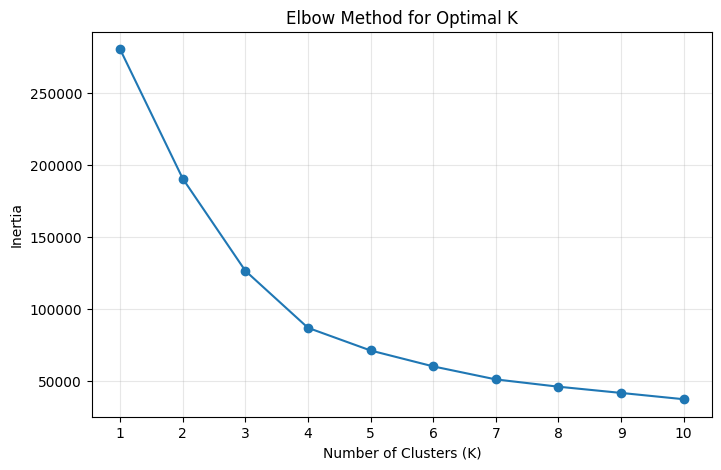

In [9]:

inertia = []
K_range = range(1, 11)
 
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)
 
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(K_range)
plt.grid(alpha=0.3)
plt.show()

In [10]:

optimal_k = 4
 
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['cluster'] = kmeans.fit_predict(rfm_scaled)
 
print("Cluster counts:")
print(rfm['cluster'].value_counts())
 

Cluster counts:
cluster
0    31970
3    31406
1    27181
2     2801
Name: count, dtype: int64


In [11]:
cluster_summary = rfm.groupby('cluster').agg(
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    customer_count=('customer_unique_id', 'count')
).round(1)
 
print(cluster_summary)

         avg_recency  avg_frequency  avg_monetary  customer_count
cluster                                                          
0              152.3            1.0          47.0           31970
1              425.9            1.0         111.3           27181
2              220.3            2.1         291.9            2801
3              164.1            1.0         271.6           31406


In [12]:
# Look at cluster_summary output above, then map labels accordingly
# (Adjust the mapping based on YOUR actual cluster numbers from Cell 8)
 
# Example logic — adjust based on what you see in cluster_summary:
def label_cluster(row):
    if row['avg_recency'] < 90 and row['avg_monetary'] > rfm['monetary'].median():
        return 'Champions'
    elif row['avg_recency'] < 90:
        return 'Recent Customers'
    elif row['avg_frequency'] > 1 and row['avg_recency'] > 180:
        return 'At Risk'
    else:
        return 'Lost Customers'
 
cluster_summary['segment_label'] = cluster_summary.apply(label_cluster, axis=1)
print(cluster_summary)
 
# Map back to main rfm table
label_map = cluster_summary['segment_label'].to_dict()
rfm['segment'] = rfm['cluster'].map(label_map)
 
print(rfm['segment'].value_counts())

         avg_recency  avg_frequency  avg_monetary  customer_count  \
cluster                                                             
0              152.3            1.0          47.0           31970   
1              425.9            1.0         111.3           27181   
2              220.3            2.1         291.9            2801   
3              164.1            1.0         271.6           31406   

          segment_label  
cluster                  
0        Lost Customers  
1        Lost Customers  
2               At Risk  
3        Lost Customers  
segment
Lost Customers    90557
At Risk            2801
Name: count, dtype: int64


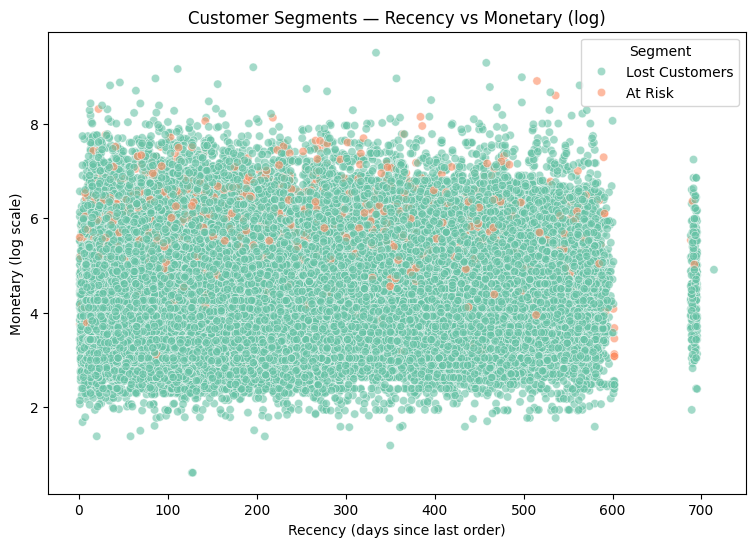

In [13]:

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=rfm, x='recency', y='monetary_log',
    hue='segment', palette='Set2', alpha=0.6
)
plt.title('Customer Segments — Recency vs Monetary (log)')
plt.xlabel('Recency (days since last order)')
plt.ylabel('Monetary (log scale)')
plt.legend(title='Segment')
plt.show()

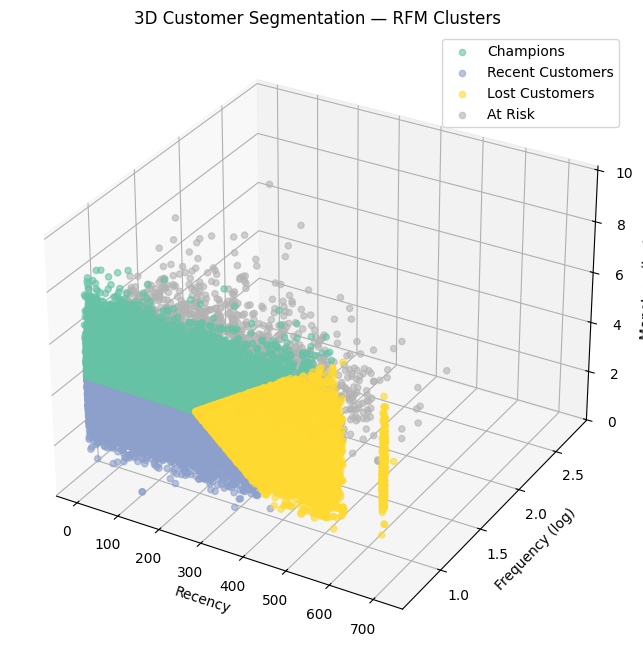

In [20]:

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
 
segments = rfm['segment'].unique()
colors = plt.cm.Set2(np.linspace(0, 1, len(segments)))
 
for seg, color in zip(segments, colors):
    subset = rfm[rfm['segment'] == seg]
    ax.scatter(
        subset['recency'], subset['frequency_log'], subset['monetary_log'],
        label=seg, color=color, alpha=0.6
    )
 
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency (log)')
ax.set_zlabel('Monetary (log)')
ax.set_title('3D Customer Segmentation — RFM Clusters')
ax.legend()
plt.show()
 

In [17]:
def label_cluster(row):
    if row['avg_recency'] < 200 and row['avg_monetary'] > 200:
        return 'Champions'
    elif row['avg_recency'] < 200 and row['avg_monetary'] <= 200:
        return 'Recent Customers'
    elif row['avg_recency'] >= 200 and row['avg_frequency'] > 1.5:
        return 'At Risk'
    else:
        return 'Lost Customers'

cluster_summary['segment_label'] = cluster_summary.apply(label_cluster, axis=1)
print(cluster_summary)

label_map = cluster_summary['segment_label'].to_dict()
rfm['segment'] = rfm['cluster'].map(label_map)

print(rfm['segment'].value_counts())

         avg_recency  avg_frequency  avg_monetary  customer_count  \
cluster                                                             
0              152.3            1.0          47.0           31970   
1              425.9            1.0         111.3           27181   
2              220.3            2.1         291.9            2801   
3              164.1            1.0         271.6           31406   

            segment_label  
cluster                    
0        Recent Customers  
1          Lost Customers  
2                 At Risk  
3               Champions  
segment
Recent Customers    31970
Champions           31406
Lost Customers      27181
At Risk              2801
Name: count, dtype: int64


In [18]:
segment_summary = rfm.groupby('segment').agg(
    customer_count=('customer_unique_id', 'count'),
    avg_recency_days=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    total_revenue=('monetary', 'sum')
).round(1).sort_values('total_revenue', ascending=False)

segment_summary['pct_of_customers'] = round(
    100 * segment_summary['customer_count'] / segment_summary['customer_count'].sum(), 1
)
segment_summary['pct_of_revenue'] = round(
    100 * segment_summary['total_revenue'] / segment_summary['total_revenue'].sum(), 1
)

print(segment_summary)

                  customer_count  avg_recency_days  avg_frequency  \
segment                                                             
Champions                  31406             164.1            1.0   
Lost Customers             27181             425.9            1.0   
Recent Customers           31970             152.3            1.0   
At Risk                     2801             220.3            2.1   

                  avg_monetary  total_revenue  pct_of_customers  \
segment                                                           
Champions                271.6      8530435.4              33.6   
Lost Customers           111.3      3025948.7              29.1   
Recent Customers          47.0      1502490.6              34.2   
At Risk                  291.9       817597.0               3.0   

                  pct_of_revenue  
segment                           
Champions                   61.5  
Lost Customers              21.8  
Recent Customers            10.8  
At Risk

In [21]:
# %% CELL 13 — Save RFM segments (useful for Power BI later)
 
rfm.to_csv('customer_rfm_segments.csv', index=False)
print("Saved customer_rfm_segments.csv ✅ — use this in Power BI for customer segment page")
 

Saved customer_rfm_segments.csv ✅ — use this in Power BI for customer segment page


## Business Interpretation — RFM Customer Segmentation

**Key Finding:** 33.6% of customers (Champions) generate 61.5% of total 
revenue — a clear Pareto-style concentration of value.

**Segment-wise recommendations:**

- **Champions (31,406 customers, 61.5% revenue):** Highest priority. 
  Reward with loyalty perks, early access to deals, premium support — 
  protect this segment at all costs.

- **At Risk (2,801 customers, 5.9% revenue but ₹291.9 avg spend — 
  HIGHEST avg spend of all segments):** These were high-value customers 
  who haven't ordered in ~220 days. Urgent win-back campaigns 
  (personalized discounts, "we miss you" emails) should target this 
  group first — they have proven high spending capacity.

- **Recent Customers (31,970, 34.2% of base, lowest avg spend ₹47):** 
  New or low-engagement customers. Focus on onboarding offers and 
  cross-sell to increase order frequency.

- **Lost Customers (27,181, 21.8% revenue, recency ~426 days):** 
  Likely churned. Low-cost reactivation emails only — not worth 
  heavy marketing investment given long inactivity.

**Business Impact:** Reallocating retention budget toward Champions and 
At Risk segments (36.6% of customers, 67.4% of revenue) instead of 
spreading equally across all 4 segments could significantly improve 
marketing ROI.